
Time column detected:
Portal Received Time

Available Signals
----------------------------------------
1. Date
2. Vehicle Number
3. VIN Number
4. Ignition Status
5. Ride Mode
6. Speed (km/h)
7. Odometer (km)
8. GPS Location
9. SOC (%)
10. Total Current (A)
11. SOH
12. Battery Pack Voltage (V)
13. Vehicle Status
14. PNRD
15. Gear Status
16. Selected Gear
17. Motor Power
18. Motor Speed
19. Motor Temp (??C)
20. MCU Temp (??C)
21. Motor Torque
22. Battery Temp (??C)
23. Max Cell Temp (??C)
24. Max Temp Box Number
25. Max Temp Cell Number
26. Min Cell Temp (??C)
27. Min Temp Box Number
28. Min Temp Cell Number
29. Max Cell Voltage (V)
30. Max Voltage Box Number
31. Max Voltage Cell Number
32. Min Cell Voltage (V)
33. Min Cell Voltage Box Number
34. Min Voltage Cell Number
35. DCDC Input Current (A)
36. DCDC Output Current (A)
37. DCDC Temp (??C)
38. BMS In Water Temp (??C)
39. Location Link
0. Exit



Choose Signal Number :  21


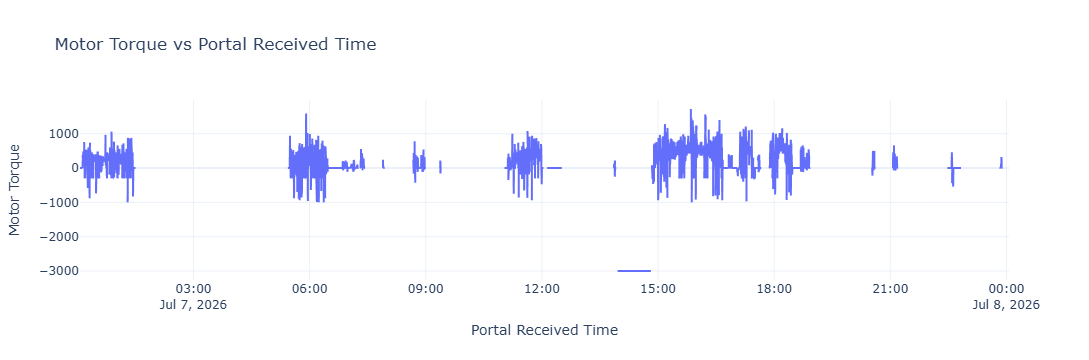


Available Signals
----------------------------------------
1. Date
2. Vehicle Number
3. VIN Number
4. Ignition Status
5. Ride Mode
6. Speed (km/h)
7. Odometer (km)
8. GPS Location
9. SOC (%)
10. Total Current (A)
11. SOH
12. Battery Pack Voltage (V)
13. Vehicle Status
14. PNRD
15. Gear Status
16. Selected Gear
17. Motor Power
18. Motor Speed
19. Motor Temp (??C)
20. MCU Temp (??C)
21. Motor Torque
22. Battery Temp (??C)
23. Max Cell Temp (??C)
24. Max Temp Box Number
25. Max Temp Cell Number
26. Min Cell Temp (??C)
27. Min Temp Box Number
28. Min Temp Cell Number
29. Max Cell Voltage (V)
30. Max Voltage Box Number
31. Max Voltage Cell Number
32. Min Cell Voltage (V)
33. Min Cell Voltage Box Number
34. Min Voltage Cell Number
35. DCDC Input Current (A)
36. DCDC Output Current (A)
37. DCDC Temp (??C)
38. BMS In Water Temp (??C)
39. Location Link
0. Exit



Choose Signal Number :  15


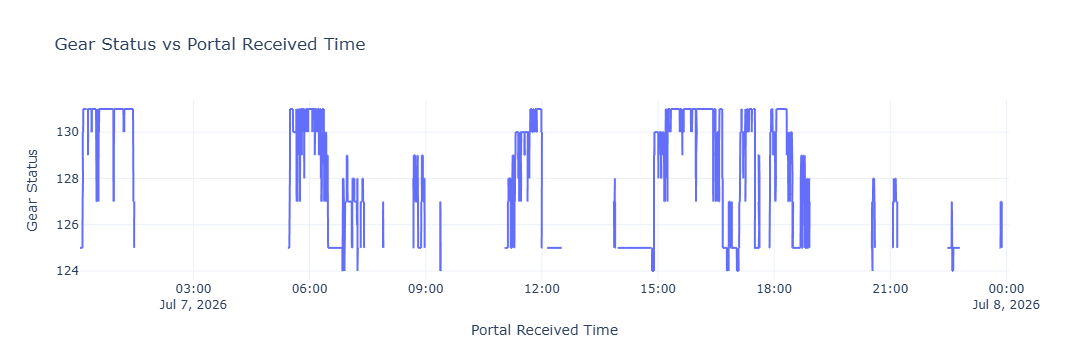


Available Signals
----------------------------------------
1. Date
2. Vehicle Number
3. VIN Number
4. Ignition Status
5. Ride Mode
6. Speed (km/h)
7. Odometer (km)
8. GPS Location
9. SOC (%)
10. Total Current (A)
11. SOH
12. Battery Pack Voltage (V)
13. Vehicle Status
14. PNRD
15. Gear Status
16. Selected Gear
17. Motor Power
18. Motor Speed
19. Motor Temp (??C)
20. MCU Temp (??C)
21. Motor Torque
22. Battery Temp (??C)
23. Max Cell Temp (??C)
24. Max Temp Box Number
25. Max Temp Cell Number
26. Min Cell Temp (??C)
27. Min Temp Box Number
28. Min Temp Cell Number
29. Max Cell Voltage (V)
30. Max Voltage Box Number
31. Max Voltage Cell Number
32. Min Cell Voltage (V)
33. Min Cell Voltage Box Number
34. Min Voltage Cell Number
35. DCDC Input Current (A)
36. DCDC Output Current (A)
37. DCDC Temp (??C)
38. BMS In Water Temp (??C)
39. Location Link
0. Exit



Choose Signal Number :  18


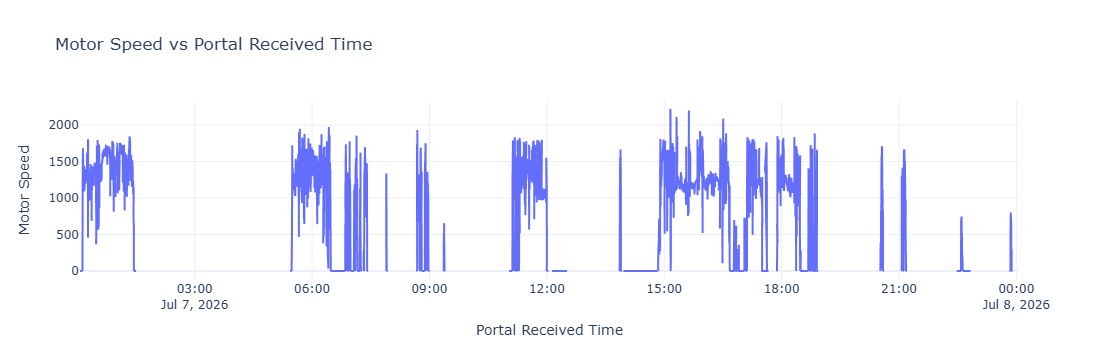


Available Signals
----------------------------------------
1. Date
2. Vehicle Number
3. VIN Number
4. Ignition Status
5. Ride Mode
6. Speed (km/h)
7. Odometer (km)
8. GPS Location
9. SOC (%)
10. Total Current (A)
11. SOH
12. Battery Pack Voltage (V)
13. Vehicle Status
14. PNRD
15. Gear Status
16. Selected Gear
17. Motor Power
18. Motor Speed
19. Motor Temp (??C)
20. MCU Temp (??C)
21. Motor Torque
22. Battery Temp (??C)
23. Max Cell Temp (??C)
24. Max Temp Box Number
25. Max Temp Cell Number
26. Min Cell Temp (??C)
27. Min Temp Box Number
28. Min Temp Cell Number
29. Max Cell Voltage (V)
30. Max Voltage Box Number
31. Max Voltage Cell Number
32. Min Cell Voltage (V)
33. Min Cell Voltage Box Number
34. Min Voltage Cell Number
35. DCDC Input Current (A)
36. DCDC Output Current (A)
37. DCDC Temp (??C)
38. BMS In Water Temp (??C)
39. Location Link
0. Exit



Choose Signal Number :  17


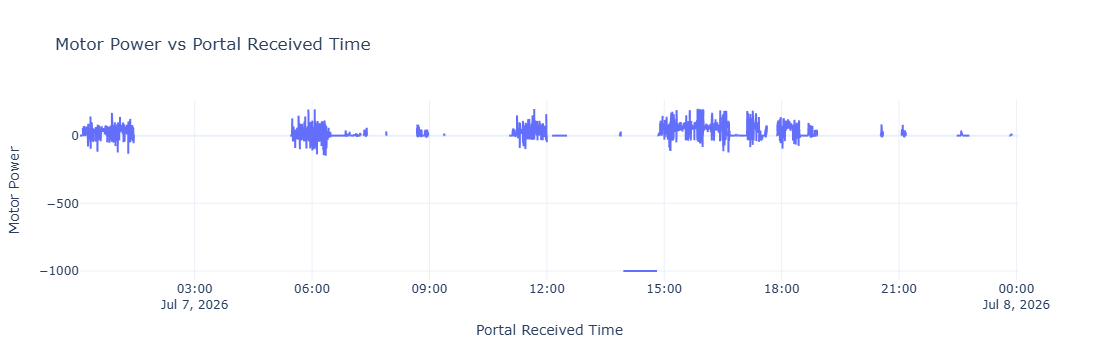


Available Signals
----------------------------------------
1. Date
2. Vehicle Number
3. VIN Number
4. Ignition Status
5. Ride Mode
6. Speed (km/h)
7. Odometer (km)
8. GPS Location
9. SOC (%)
10. Total Current (A)
11. SOH
12. Battery Pack Voltage (V)
13. Vehicle Status
14. PNRD
15. Gear Status
16. Selected Gear
17. Motor Power
18. Motor Speed
19. Motor Temp (??C)
20. MCU Temp (??C)
21. Motor Torque
22. Battery Temp (??C)
23. Max Cell Temp (??C)
24. Max Temp Box Number
25. Max Temp Cell Number
26. Min Cell Temp (??C)
27. Min Temp Box Number
28. Min Temp Cell Number
29. Max Cell Voltage (V)
30. Max Voltage Box Number
31. Max Voltage Cell Number
32. Min Cell Voltage (V)
33. Min Cell Voltage Box Number
34. Min Voltage Cell Number
35. DCDC Input Current (A)
36. DCDC Output Current (A)
37. DCDC Temp (??C)
38. BMS In Water Temp (??C)
39. Location Link
0. Exit



Choose Signal Number :  0


In [1]:
import pandas as pd
import plotly.express as px

# --------------------------------------------------
# Load Excel File
# --------------------------------------------------
file_path = r"vehicle-data-report (4).xlsx"      # Change file name here

df = pd.read_excel(file_path)

# --------------------------------------------------
# Automatically detect Time column
# --------------------------------------------------
time_candidates = [c for c in df.columns if "time" in c.lower()]

if len(time_candidates) == 0:
    raise Exception("No Time column found!")

time_col = time_candidates[0]

print("\nTime column detected:")
print(time_col)

# --------------------------------------------------
# Get all Y-axis signals
# --------------------------------------------------
signals = [c for c in df.columns if c != time_col]

while True:

    print("\nAvailable Signals")
    print("-"*40)

    for i, sig in enumerate(signals, start=1):
        print(f"{i}. {sig}")

    print("0. Exit")

    try:
        choice = int(input("\nChoose Signal Number : "))

        if choice == 0:
            break

        if choice < 1 or choice > len(signals):
            print("Invalid Selection")
            continue

        y_col = signals[choice-1]

        fig = px.line(
            df,
            x=time_col,
            y=y_col,
            title=f"{y_col} vs {time_col}",
            markers=False
        )

        fig.update_layout(
            xaxis_title=time_col,
            yaxis_title=y_col,
            hovermode="x unified",
            template="plotly_white"
        )

        fig.show()

    except Exception as e:
        print(e)

In [2]:
# Automatically detect the Time column
time_candidates = [c for c in df.columns if "time" in c.lower()]

if len(time_candidates) == 0:
    raise Exception("No Time column found!")

time_col = time_candidates[0]

# Convert to datetime
df[time_col] = pd.to_datetime(df[time_col])

# Compute elapsed time in seconds from the first sample
df["Time (s)"] = (df[time_col] - df[time_col].iloc[0]).dt.total_seconds()

# Use elapsed time as X-axis
time_col = "Time (s)"

In [3]:
print(time_col)

Time (s)



Time column detected: Portal Received Time

Available Signals
----------------------------------------
1. Date
2. Vehicle Number
3. VIN Number
4. Portal Received Time
5. Ignition Status
6. Ride Mode
7. Speed (km/h)
8. Odometer (km)
9. GPS Location
10. SOC (%)
11. Total Current (A)
12. SOH
13. Battery Pack Voltage (V)
14. Vehicle Status
15. PNRD
16. Gear Status
17. Selected Gear
18. Motor Power
19. Motor Speed
20. Motor Temp (??C)
21. MCU Temp (??C)
22. Motor Torque
23. Battery Temp (??C)
24. Max Cell Temp (??C)
25. Max Temp Box Number
26. Max Temp Cell Number
27. Min Cell Temp (??C)
28. Min Temp Box Number
29. Min Temp Cell Number
30. Max Cell Voltage (V)
31. Max Voltage Box Number
32. Max Voltage Cell Number
33. Min Cell Voltage (V)
34. Min Cell Voltage Box Number
35. Min Voltage Cell Number
36. DCDC Input Current (A)
37. DCDC Output Current (A)
38. DCDC Temp (??C)
39. BMS In Water Temp (??C)
40. Location Link
0. Exit



Choose Signal Number :  22


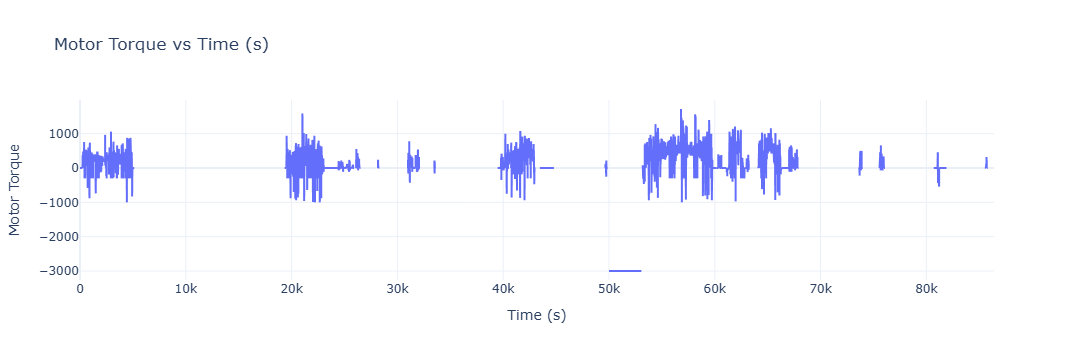


Available Signals
----------------------------------------
1. Date
2. Vehicle Number
3. VIN Number
4. Portal Received Time
5. Ignition Status
6. Ride Mode
7. Speed (km/h)
8. Odometer (km)
9. GPS Location
10. SOC (%)
11. Total Current (A)
12. SOH
13. Battery Pack Voltage (V)
14. Vehicle Status
15. PNRD
16. Gear Status
17. Selected Gear
18. Motor Power
19. Motor Speed
20. Motor Temp (??C)
21. MCU Temp (??C)
22. Motor Torque
23. Battery Temp (??C)
24. Max Cell Temp (??C)
25. Max Temp Box Number
26. Max Temp Cell Number
27. Min Cell Temp (??C)
28. Min Temp Box Number
29. Min Temp Cell Number
30. Max Cell Voltage (V)
31. Max Voltage Box Number
32. Max Voltage Cell Number
33. Min Cell Voltage (V)
34. Min Cell Voltage Box Number
35. Min Voltage Cell Number
36. DCDC Input Current (A)
37. DCDC Output Current (A)
38. DCDC Temp (??C)
39. BMS In Water Temp (??C)
40. Location Link
0. Exit



Choose Signal Number :  0


In [5]:
import pandas as pd
import plotly.express as px

# --------------------------------------------------
# Load Excel File
# --------------------------------------------------
file_path = r"vehicle-data-report (4).xlsx"      # Change file name here

df = pd.read_excel(file_path)

# --------------------------------------------------
# Automatically detect Time column
# --------------------------------------------------
time_candidates = [c for c in df.columns if "time" in c.lower()]

if len(time_candidates) == 0:
    raise Exception("No Time column found!")

original_time_col = time_candidates[0]

print("\nTime column detected:", original_time_col)

# --------------------------------------------------
# Convert Time column to datetime
# --------------------------------------------------
df[original_time_col] = pd.to_datetime(df[original_time_col])

# --------------------------------------------------
# Sort data by Time (Oldest -> Newest)
# --------------------------------------------------
df = df.sort_values(by=original_time_col)

# Reset row numbers
df.reset_index(drop=True, inplace=True)

# --------------------------------------------------
# Calculate elapsed time in seconds
# --------------------------------------------------
df["Time (s)"] = (
    df[original_time_col] - df[original_time_col].iloc[0]
).dt.total_seconds()

# Use elapsed seconds as X-axis
time_col = "Time (s)"

# --------------------------------------------------
# Get all Y-axis signals
# --------------------------------------------------
signals = [c for c in df.columns if c != time_col]

while True:

    print("\nAvailable Signals")
    print("-"*40)

    for i, sig in enumerate(signals, start=1):
        print(f"{i}. {sig}")

    print("0. Exit")

    try:
        choice = int(input("\nChoose Signal Number : "))

        if choice == 0:
            break

        if choice < 1 or choice > len(signals):
            print("Invalid Selection")
            continue

        y_col = signals[choice-1]

        fig = px.line(
            df,
            x=time_col,
            y=y_col,
            title=f"{y_col} vs {time_col}",
            markers=False
        )

        fig.update_layout(
            xaxis_title=time_col,
            yaxis_title=y_col,
            hovermode="x unified",
            template="plotly_white"
        )

        fig.show()

    except Exception as e:
        print(e)


Time column detected: Portal Received Time

Available Signals
----------------------------------------
1. Date
2. Vehicle Number
3. VIN Number
4. Ignition Status
5. Ride Mode
6. Speed (km/h)
7. Odometer (km)
8. GPS Location
9. SOC (%)
10. Total Current (A)
11. SOH
12. Battery Pack Voltage (V)
13. Vehicle Status
14. PNRD
15. Gear Status
16. Selected Gear
17. Motor Power
18. Motor Speed
19. Motor Temp (??C)
20. MCU Temp (??C)
21. Motor Torque
22. Battery Temp (??C)
23. Max Cell Temp (??C)
24. Max Temp Box Number
25. Max Temp Cell Number
26. Min Cell Temp (??C)
27. Min Temp Box Number
28. Min Temp Cell Number
29. Max Cell Voltage (V)
30. Max Voltage Box Number
31. Max Voltage Cell Number
32. Min Cell Voltage (V)
33. Min Cell Voltage Box Number
34. Min Voltage Cell Number
35. DCDC Input Current (A)
36. DCDC Output Current (A)
37. DCDC Temp (??C)
38. BMS In Water Temp (??C)
39. Location Link
0. Exit



Choose Signal Number :  21


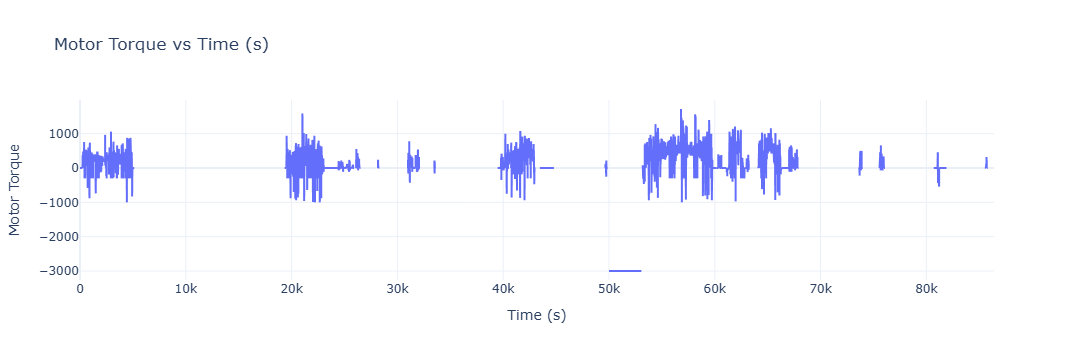


Available Signals
----------------------------------------
1. Date
2. Vehicle Number
3. VIN Number
4. Ignition Status
5. Ride Mode
6. Speed (km/h)
7. Odometer (km)
8. GPS Location
9. SOC (%)
10. Total Current (A)
11. SOH
12. Battery Pack Voltage (V)
13. Vehicle Status
14. PNRD
15. Gear Status
16. Selected Gear
17. Motor Power
18. Motor Speed
19. Motor Temp (??C)
20. MCU Temp (??C)
21. Motor Torque
22. Battery Temp (??C)
23. Max Cell Temp (??C)
24. Max Temp Box Number
25. Max Temp Cell Number
26. Min Cell Temp (??C)
27. Min Temp Box Number
28. Min Temp Cell Number
29. Max Cell Voltage (V)
30. Max Voltage Box Number
31. Max Voltage Cell Number
32. Min Cell Voltage (V)
33. Min Cell Voltage Box Number
34. Min Voltage Cell Number
35. DCDC Input Current (A)
36. DCDC Output Current (A)
37. DCDC Temp (??C)
38. BMS In Water Temp (??C)
39. Location Link
0. Exit



Choose Signal Number :  0


In [7]:
import pandas as pd
import plotly.express as px

# --------------------------------------------------
# Load Excel File
# --------------------------------------------------
file_path = r"vehicle-data-report (4).xlsx"      # Change file name here

df = pd.read_excel(file_path)

# --------------------------------------------------
# Automatically detect Time column
# --------------------------------------------------
time_candidates = [c for c in df.columns if "time" in c.lower()]

if len(time_candidates) == 0:
    raise Exception("No Time column found!")

original_time_col = time_candidates[0]

print("\nTime column detected:", original_time_col)

# --------------------------------------------------
# Convert Time column to datetime
# --------------------------------------------------
df[original_time_col] = pd.to_datetime(df[original_time_col])

# --------------------------------------------------
# Sort data by Time (Oldest -> Newest)
# --------------------------------------------------
df = df.sort_values(by=original_time_col)

# Reset row numbers
df.reset_index(drop=True, inplace=True)

# --------------------------------------------------
# Calculate elapsed time in seconds
# --------------------------------------------------
df["Time (s)"] = (
    df[original_time_col] - df[original_time_col].iloc[0]
).dt.total_seconds()

# Use elapsed seconds as X-axis
time_col = "Time (s)"
# --------------------------------------------------
# Get all Y-axis signals
# --------------------------------------------------
signals = [
    c for c in df.columns
    if c not in [original_time_col, "Time (s)"]
]

while True:

    print("\nAvailable Signals")
    print("-"*40)

    for i, sig in enumerate(signals, start=1):
        print(f"{i}. {sig}")

    print("0. Exit")

    try:
        choice = int(input("\nChoose Signal Number : "))

        if choice == 0:
            break

        if choice < 1 or choice > len(signals):
            print("Invalid Selection")
            continue

        y_col = signals[choice-1]

        fig = px.line(
            df,
            x=time_col,
            y=y_col,
            title=f"{y_col} vs {time_col}",
            markers=False
        )

        fig.update_layout(
            xaxis_title=time_col,
            yaxis_title=y_col,
            hovermode="x unified",
            template="plotly_white"
        )

        fig.show()

    except Exception as e:
        print(e)


Time column detected: Time

Available Signals
----------------------------------------
1. Speed (km/h)
2. Vehicle Status
3. Gear Status
4. Selected Gear
5. Motor Power
6. Motor Speed
7. Motor Torque
0. Exit



Choose Signal Number :  7


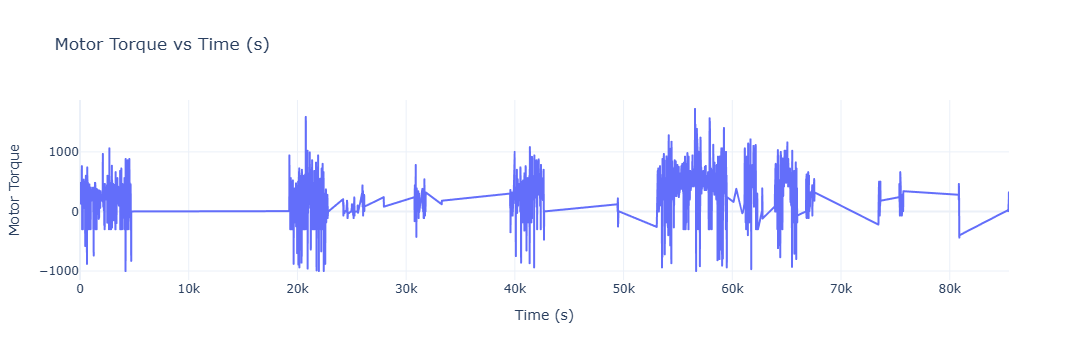


Available Signals
----------------------------------------
1. Speed (km/h)
2. Vehicle Status
3. Gear Status
4. Selected Gear
5. Motor Power
6. Motor Speed
7. Motor Torque
0. Exit



Choose Signal Number :  1


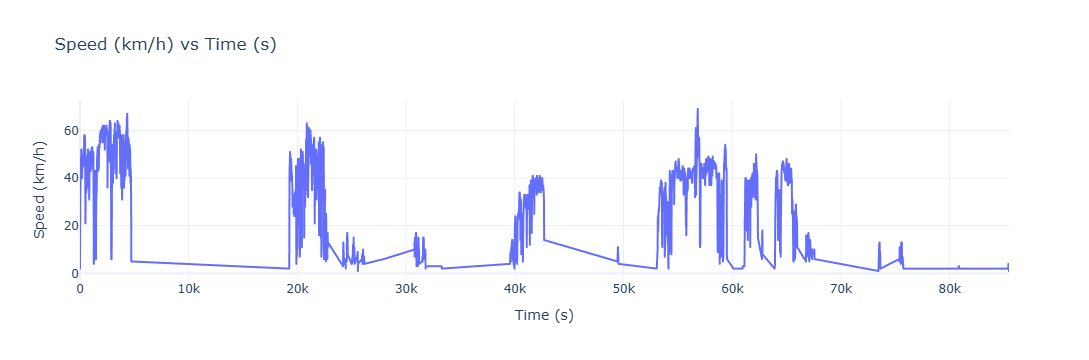


Available Signals
----------------------------------------
1. Speed (km/h)
2. Vehicle Status
3. Gear Status
4. Selected Gear
5. Motor Power
6. Motor Speed
7. Motor Torque
0. Exit



Choose Signal Number :  4


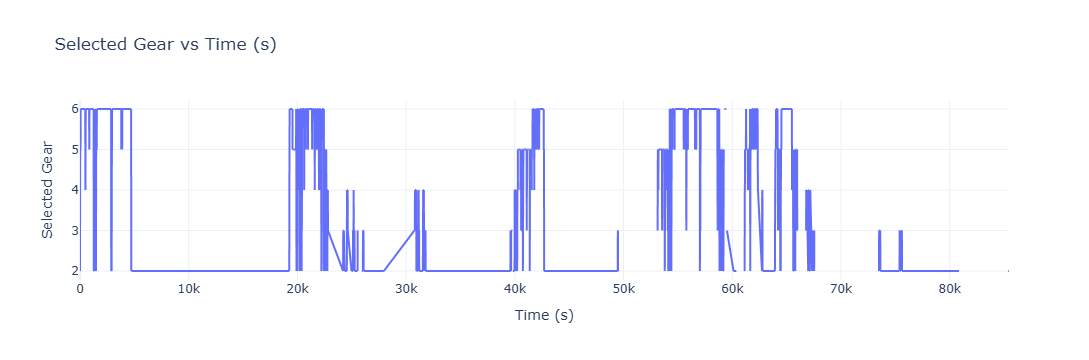


Available Signals
----------------------------------------
1. Speed (km/h)
2. Vehicle Status
3. Gear Status
4. Selected Gear
5. Motor Power
6. Motor Speed
7. Motor Torque
0. Exit



Choose Signal Number :  3


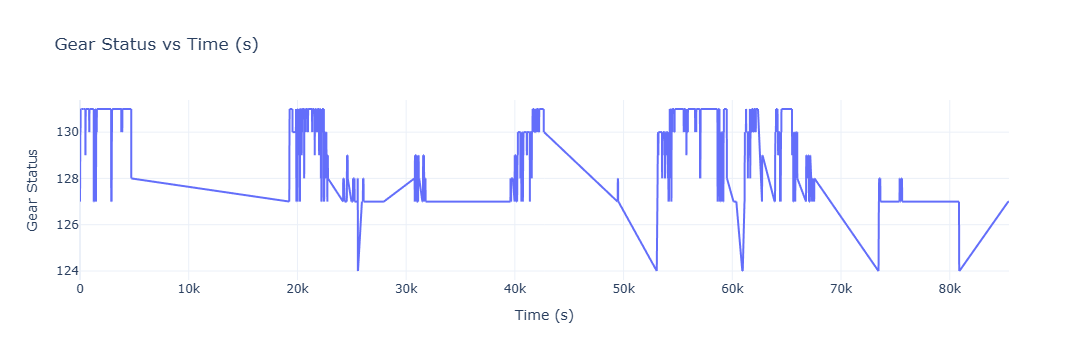


Available Signals
----------------------------------------
1. Speed (km/h)
2. Vehicle Status
3. Gear Status
4. Selected Gear
5. Motor Power
6. Motor Speed
7. Motor Torque
0. Exit



Choose Signal Number :  0


In [11]:
0



Time column detected: Time

Available Signals
----------------------------------------
1. Speed (km/h)
2. Vehicle Status
3. PNRD
4. Gear Status
5. Motor Power
6. Motor Speed
7. Motor Torque
0. Exit



Choose Signal Number :  1


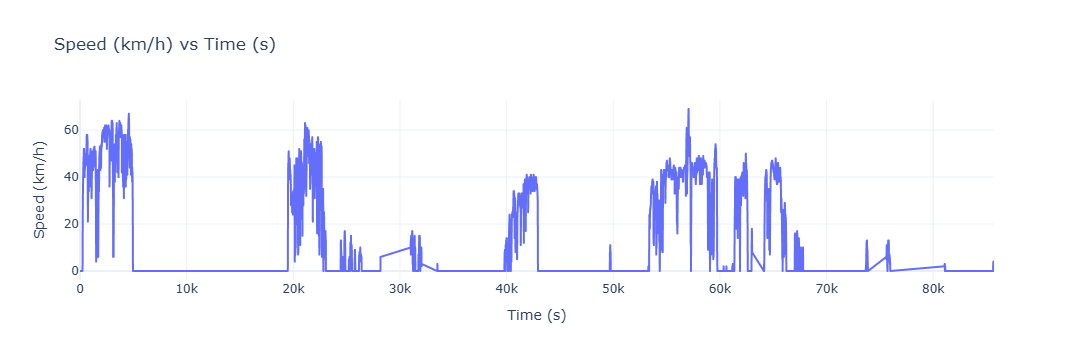


Available Signals
----------------------------------------
1. Speed (km/h)
2. Vehicle Status
3. PNRD
4. Gear Status
5. Motor Power
6. Motor Speed
7. Motor Torque
0. Exit



Choose Signal Number :  4


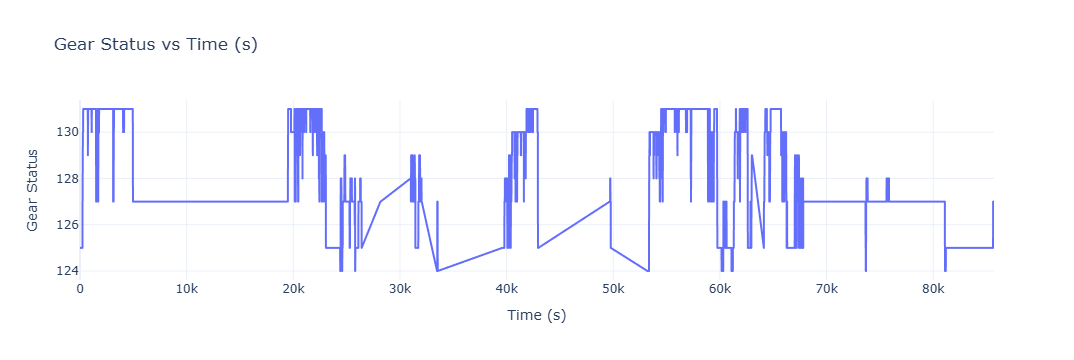


Available Signals
----------------------------------------
1. Speed (km/h)
2. Vehicle Status
3. PNRD
4. Gear Status
5. Motor Power
6. Motor Speed
7. Motor Torque
0. Exit



Choose Signal Number :  7


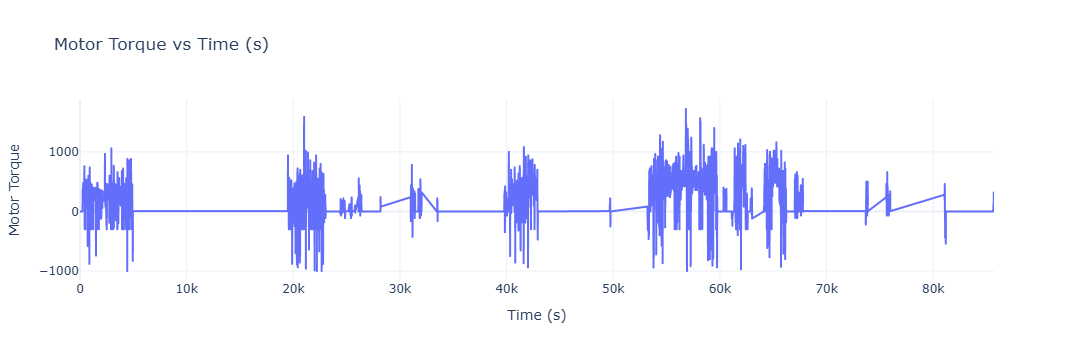


Available Signals
----------------------------------------
1. Speed (km/h)
2. Vehicle Status
3. PNRD
4. Gear Status
5. Motor Power
6. Motor Speed
7. Motor Torque
0. Exit



Choose Signal Number :  0


In [ ]:
import pandas as pd
import plotly.express as px

# --------------------------------------------------
# Load Excel File
# --------------------------------------------------
file_path = r"TN61AC3987_modified_1.xlsx"      # Change file name here

df = pd.read_excel(file_path)

# --------------------------------------------------
# Automatically detect Time column
# --------------------------------------------------
time_candidates = [c for c in df.columns if "time" in c.lower()]

if len(time_candidates) == 0:
    raise Exception("No Time column found!")

original_time_col = time_candidates[0]

print("\nTime column detected:", original_time_col)

# --------------------------------------------------
# Convert Time column to datetime
# --------------------------------------------------
df[original_time_col] = pd.to_datetime(df[original_time_col])

# --------------------------------------------------
# Sort data by Time (Oldest -> Newest)
# --------------------------------------------------
df = df.sort_values(by=original_time_col)

# Reset row numbers
df.reset_index(drop=True, inplace=True)

# --------------------------------------------------
# Calculate elapsed time in seconds
# --------------------------------------------------
df["Time (s)"] = (
    df[original_time_col] - df[original_time_col].iloc[0]
).dt.total_seconds()

# Use elapsed seconds as X-axis
time_col = "Time (s)"
# --------------------------------------------------
# Get all Y-axis signals
# --------------------------------------------------
signals = [
    c for c in df.columns
    if c not in [original_time_col, "Time (s)"]
]

while True:

    print("\nAvailable Signals")
    print("-"*40)

    for i, sig in enumerate(signals, start=1):
        print(f"{i}. {sig}")

    print("0. Exit")

    try:
        choice = int(input("\nChoose Signal Number : "))

        if choice == 0:
            break

        if choice < 1 or choice > len(signals):
            print("Invalid Selection")
            continue

        y_col = signals[choice-1]

        fig = px.line(
            df,
            x=time_col,
            y=y_col,
            title=f"{y_col} vs {time_col}",
            markers=False
        )

        fig.update_layout(
            xaxis_title=time_col,
            yaxis_title=y_col,
            hovermode="x unified",
            template="plotly_white"
        )

        fig.show()

    except Exception as e:
        print(e)

In [ ]:
import pandas as pd
import plotly.express as px

# --------------------------------------------------
# Load Excel File
# --------------------------------------------------
file_path = r"TN61AC3987_modified_1.xlsx"      # Change file name here

df = pd.read_excel(file_path)

# --------------------------------------------------
# Automatically detect Time column
# --------------------------------------------------
time_candidates = [c for c in df.columns if "time" in c.lower()]

if len(time_candidates) == 0:
    raise Exception("No Time column found!")

original_time_col = time_candidates[0]

print("\nTime column detected:", original_time_col)

# --------------------------------------------------
# Convert Time column to datetime
# --------------------------------------------------
df[original_time_col] = pd.to_datetime(df[original_time_col])

# --------------------------------------------------
# Sort data by Time (Oldest -> Newest)
# --------------------------------------------------
df = df.sort_values(by=original_time_col)

# Reset row numbers
df.reset_index(drop=True, inplace=True)

# --------------------------------------------------
# Calculate elapsed time in seconds
# --------------------------------------------------
df["Time (s)"] = (
    df[original_time_col] - df[original_time_col].iloc[0]
).dt.total_seconds()

# Use elapsed seconds as X-axis
time_col = "Time (s)"

# --------------------------------------------------
# Transmission Output Torque & Speed
# --------------------------------------------------

# ======== Change these three names according to your Excel ========
gear_col = "Gear Status"
motor_speed_col = "Motor Speed"
motor_torque_col = "MCU1_N_MotorTorque"

# Check whether required columns exist
required_cols = [gear_col, motor_speed_col, motor_torque_col]

missing = [col for col in required_cols if col not in df.columns]

if missing:
    print("\nMissing Columns:")
    print(missing)
    raise Exception("Please update the column names in the code.")

# --------------------------------------------------
# Gear Status Mapping
# --------------------------------------------------

gear_status_map = {
    124: -1,
    125: 0,
    126: 1,
    127: 2,
    128: 3,
    129: 4,
    130: 5,
    131: 6
}

# --------------------------------------------------
# Gear Ratios
# --------------------------------------------------

gear_ratio = {
    -1: 11.90,
     0: 0.00,
     1: 11.90,
     2: 7.26,
     3: 4.44,
     4: 2.68,
     5: 1.63,
     6: 1.00
}

# Decode Gear Status
df["Gear"] = df[gear_col].map(gear_status_map)

# Gear Ratio
df["Gear Ratio"] = df["Gear"].map(gear_ratio)

# Transmission Efficiency (optional)
efficiency = 0.97

# Neutral handling
ratio = df["Gear Ratio"].replace(0, pd.NA)

# --------------------------------------------------
# Output Speed
# --------------------------------------------------

df["Transmission_Output_Speed (rpm)"] = (
    df[motor_speed_col] / ratio
)

# --------------------------------------------------
# Output Torque
# --------------------------------------------------

df["Transmission_Output_Torque (Nm)"] = (
    df[motor_torque_col] * ratio * efficiency
)

# Neutral values = 0
df["Transmission_Output_Speed (rpm)"] = (
    df["Transmission_Output_Speed (rpm)"].fillna(0)
)

df["Transmission_Output_Torque (Nm)"] = (
    df["Transmission_Output_Torque (Nm)"].fillna(0)
)

print("\nTransmission Output Calculated Successfully")
# --------------------------------------------------
# Get all Y-axis signals
# --------------------------------------------------
signals = [
    c for c in df.columns
    if c not in [original_time_col, "Time (s)"]
]

while True:

    print("\nAvailable Signals")
    print("-"*40)

    for i, sig in enumerate(signals, start=1):
        print(f"{i}. {sig}")

    print("0. Exit")

    try:
        choice = int(input("\nChoose Signal Number : "))

        if choice == 0:
            break

        if choice < 1 or choice > len(signals):
            print("Invalid Selection")
            continue

        y_col = signals[choice-1]

        fig = px.line(
            df,
            x=time_col,
            y=y_col,
            title=f"{y_col} vs {time_col}",
            markers=False
        )

        fig.update_layout(
            xaxis_title=time_col,
            yaxis_title=y_col,
            hovermode="x unified",
            template="plotly_white"
        )

        fig.show()

    except Exception as e:
        print(e)